In [214]:
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.inspection import permutation_importance


In [215]:
df_org_LR=pd.read_csv('Data/Bank Customer Churn Prediction.csv')
df_org_LR=df_org_LR.drop('customer_id',axis=1)
df_org_LR.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


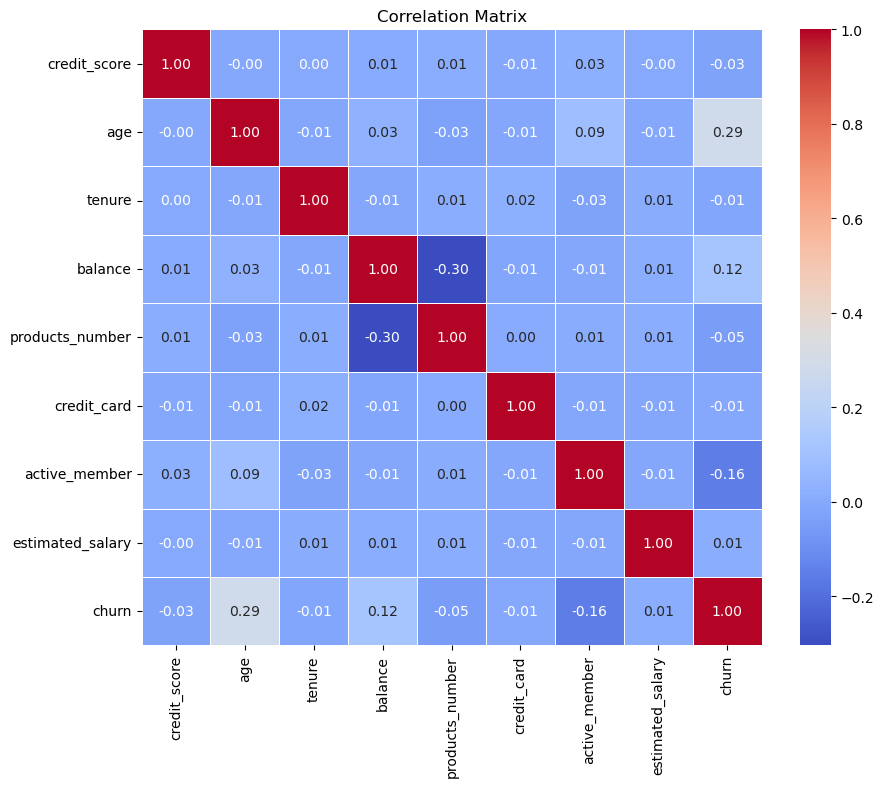

In [216]:
num_df_org_lr=df_org_LR.select_dtypes(include=['int64','float64'])
cat_df_org_lr=df_org_LR.select_dtypes(include=['object','string'])
corr=num_df_org_lr.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True,fmt='.2f',cmap='coolwarm',linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

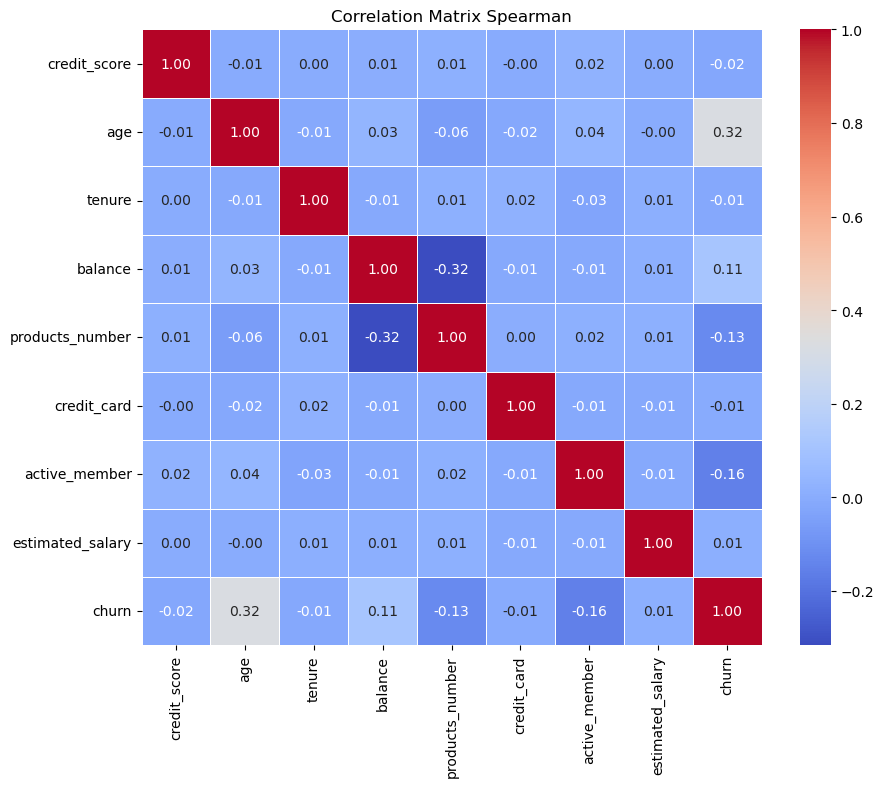

In [217]:
corr=num_df_org_lr.corr(method='spearman')
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True,fmt='.2f',cmap='coolwarm',linewidths=.5)
plt.title('Correlation Matrix Spearman')
plt.show()

### Brak wyraznych korelacji

In [218]:
# for col in num_df_org_lr.columns:
#     plt.figure(figsize=(10,6))
#     sns.boxplot(data=num_df_org_lr[col])
#     plt.title("Boxplot - Outliers detection")
#     plt.show()

### brak nielogicznych outliers


In [219]:
y=df_org_LR['churn']
X=df_org_LR.drop('churn',axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
def feature_in_Lr(df):
    df=df.copy()
    #df['has_balance']=(df['balance']>0).astype(int)
    df['balance_log']=np.log1p(df['balance'])
    df['age_log'] = np.log1p(df['age'])
    df['tenure>2']=(df['tenure']>=2).astype(int)
    df['products_number']=df['products_number'].astype('string')
    col_to_drop = ['age','balance','credit_score','tenure','credit_card']
    df=df.drop(col_to_drop,axis=1)
    return df
X_train=feature_in_Lr(X_train)
X_test=feature_in_Lr(X_test)
num_X_lr = X_train.select_dtypes(include=['int64','float64']).columns
cat_X_lr = X_train.select_dtypes(include=['object','string']).columns

num_piline=Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
cat_piline=Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
prepecesing_LR=ColumnTransformer([
    ('num_piline', num_piline, num_X_lr),
    ('cat_piline', cat_piline, cat_X_lr),
])
model_LR=Pipeline([('preporc',prepecesing_LR),
                   ('m_LR', LogisticRegression())
                   ])



In [220]:

for test in ["precision", "recall", "roc_auc"]:
    punkty_model_LR=cross_val_score(estimator=model_LR,X=X_train,y=y_train, cv=5,scoring=test)
    print(test,": ", punkty_model_LR.mean().round(2))

precision :  0.71
recall :  0.39
roc_auc :  0.83


### wyniki startowe
precision :  0.6
recall :  0.22
roc_auc :  0.76

In [221]:
from sklearn.inspection import permutation_importance

model_LR.fit(X_train, y_train)

for sco in ["roc_auc"]:
    f_imp = permutation_importance(
        estimator=model_LR,
        X=X_test,
        y=y_test,
        n_jobs=-1,
        random_state=42,
        scoring=sco,
        n_repeats=10
    )

    df_f_imp = pd.DataFrame({
        'feature': X_test.columns,
        'importance': f_imp.importances_mean
    }).sort_values(by='importance', ascending=False)

    print(sco, ":\n", df_f_imp)

roc_auc :
             feature  importance
2   products_number    0.124023
6           age_log    0.099578
3     active_member    0.037783
0           country    0.019147
1            gender    0.011839
5       balance_log    0.001795
7          tenure>2    0.000860
4  estimated_salary   -0.000554


In [222]:
X_test_transformed = model_LR.named_steps['preporc'].transform(X_test)
lr_model = model_LR.named_steps['m_LR']

f_imp = permutation_importance(
    estimator=lr_model,
    X=X_test_transformed,
    y=y_test,
    n_jobs=-1,
    random_state=42,
    scoring="roc_auc",
    n_repeats=10
)

feature_names = model_LR.named_steps['preporc'].get_feature_names_out()

df_f_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': f_imp.importances_mean
}).sort_values(by='importance', ascending=False)

print(df_f_imp)

                          feature  importance
11  cat_piline__products_number_2    0.185694
3             num_piline__age_log    0.099578
0       num_piline__active_member    0.037783
10  cat_piline__products_number_1    0.030017
6     cat_piline__country_Germany    0.006679
12  cat_piline__products_number_3    0.005286
8       cat_piline__gender_Female    0.004192
9         cat_piline__gender_Male    0.003444
7       cat_piline__country_Spain    0.001840
2         num_piline__balance_log    0.001795
13  cat_piline__products_number_4    0.001379
5      cat_piline__country_France    0.001277
4            num_piline__tenure>2    0.000860
1    num_piline__estimated_salary   -0.000554


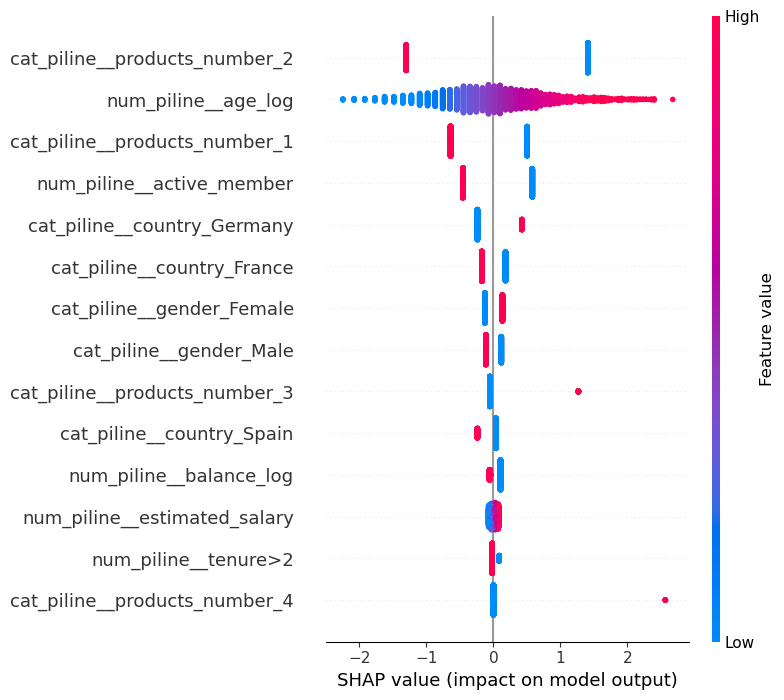

In [223]:

model_LR.fit(X_train, y_train)

preproc = model_LR.named_steps['preporc']
lr_model = model_LR.named_steps['m_LR']

X_train_t = preproc.transform(X_train)
X_test_t = preproc.transform(X_test)

feature_names = preproc.get_feature_names_out()

explainer = shap.LinearExplainer(lr_model, X_train_t)

shap_values = explainer(X_test_t)

plt.figure()
shap.summary_plot(shap_values, X_test_t, feature_names=feature_names)
plt.show()
